In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.cm import get_cmap
import metpy.calc as mpcalc
from metpy.units import units
from numpy import *
import xarray as xr
from netCDF4 import Dataset, num2date
import math
import pygrib
import cdsapi
from datetime import datetime, timedelta
from geopy.distance import geodesic
import numpy as np

In [7]:
############# Declare time, level, and lat/lon boundaries here ##########
startdate = '02/01/26 00:00'    ## must be in this format 'MM/DD/YY HH:MM'
latN = 50 # 90
latS = 0
lonW = 250 # 180  # -180
lonE = 320 # 330   # 0
date = datetime.strptime(startdate,'%m/%d/%y %H:%M')
level = 500

In [8]:
### Import Data ###

# Vorticity Data
#filerv_2_1 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_138_vo.ll025sc.2026020100_2026020123.nc' # relative vorticity
filepv_2_1 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_060_pv.ll025sc.2026020100_2026020123.nc'
filepv_1_31 = '/gdex/data/d633000/e5.oper.an.pl/202601/e5.oper.an.pl.128_060_pv.ll025sc.2026013100_2026013123.nc'
filepv_2_2 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_060_pv.ll025sc.2026020200_2026020223.nc'

dpv_2_1 = xr.open_dataset(filepv_2_1).metpy.parse_cf()
dpv_1_31 = xr.open_dataset(filepv_1_31).metpy.parse_cf()
dpv_2_2 = xr.open_dataset(filepv_2_2).metpy.parse_cf()
#print(list(dpv_2_1.data_vars))

# IVT Data
filevt_2_1 = '/gdex/data/d633000/e5.oper.an.sfc/202602/e5.oper.an.sfc.128_137_tcwv.ll025sc.2026020100_2026022823.nc' # total column water vapor - this variable is monthly so this is importing for all of feb
filevt_jan = '/gdex/data/d633000/e5.oper.an.sfc/202601/e5.oper.an.sfc.128_137_tcwv.ll025sc.2026010100_2026013123.nc' # TCWV for all of jan - want to isolate from 30 or 31 on

dvt_2_1 = xr.open_dataset(filevt_2_1).metpy.parse_cf()
dvt_jan = xr.open_dataset(filevt_jan).metpy.parse_cf()
#print(list(dvt_2_1.data_vars))

# Wind for relative vorticity calcs
'''
fileuwnd_2_1 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_131_u.ll025uv.2026020100_2026020123.nc'
filevwnd_2_1 = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_132_v.ll025uv.2026020100_2026020123.nc'
duwnd_2_1 = xr.open_dataset(fileuwnd_2_1).metpy.parse_cf()
dvwnd_2_1 = xr.open_dataset(filevwnd_2_1).metpy.parse_cf()
'''

# Read Variables
# vorticity and IVT
pv_2_1 = dpv_2_1.PV.metpy.sel(level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE)) #VO for rv, PV for pv
pv_1_31 = dpv_1_31.PV.metpy.sel(level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE)) 
pv_2_2 = dpv_2_2.PV.metpy.sel(level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE)) 

vt_2_1 = dvt_2_1.TCWV.metpy.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
vt_jan = dvt_jan.TCWV.metpy.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
print(vt_2_1)
print(vt_jan)

# concatenating the data sets for entire storm
dpv_storm = xr.concat([pv_1_31, pv_2_1, pv_2_2], dim='time')
dvt_storm = xr.concat([vt_jan, vt_2_1], dim='time')

# selecting time 
dpv_storm = dpv_storm.sel(time=slice('2026-01-31','2026-02-02T23:00'))
dvt_storm = dvt_storm.sel(time=slice('2026-01-31','2026-02-02T23:00'))

# wind
'''
uwnd_2_1 = duwnd_2_1.U.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
vwnd_2_1 = dvwnd_2_1.V.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
'''

# Mesh grid lat lon
lats = dpv_2_1.latitude.metpy.sel(latitude=slice(latN,latS))
lons = dpv_2_1.longitude.metpy.sel(longitude=slice(lonW,lonE))

lons_2D, lats_2D = meshgrid(lons,lats)
lats_2D = lats_2D * units.degrees
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)

<xarray.DataArray 'TCWV' (time: 672, latitude: 201, longitude: 281)> Size: 152MB
[37955232 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 5kB 2026-02-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 2kB 50.0 49.75 49.5 49.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 2kB 250.0 250.2 250.5 ... 319.5 319.8 320.0
    metpy_crs  object 8B Projection: latitude_longitude
Attributes: (12/15)
    long_name:           Total column water vapour
    short_name:          tcwv
    units:               kg m**-2
    original_format:     WMO GRIB 1 with ECMWF local table
    ecmwf_local_table:   128
    ecmwf_parameter:     137
    ...                  ...
    rda_dataset:         ds633.0
    rda_dataset_url:     https:/rda.ucar.edu/datasets/ds633.0/
    rda_dataset_doi:     DOI: 10.5065/BH6N-5N20
    rda_dataset_group:   ERA5 atmospheric surface analysis [netCDF4]
    quantization:        quantization_info
    quantization_nsd:    7
<xarray.DataArray

2026-01-31T12:00:00.000000000


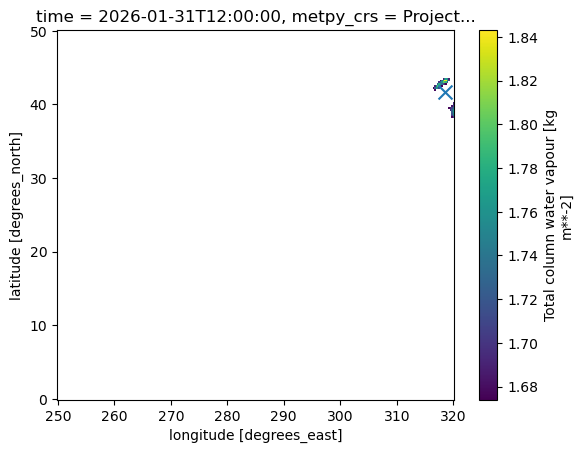

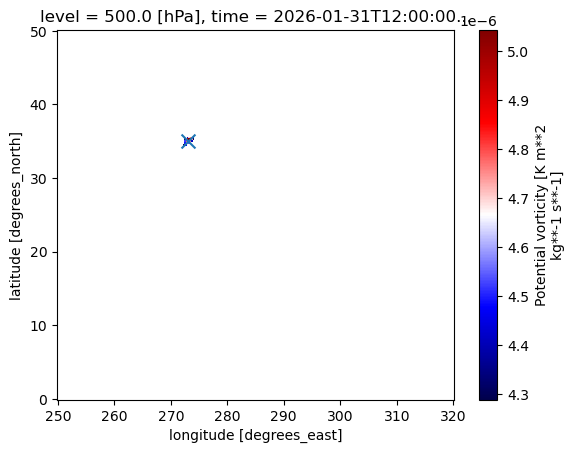

2026-01-31T16:00:00.000000000


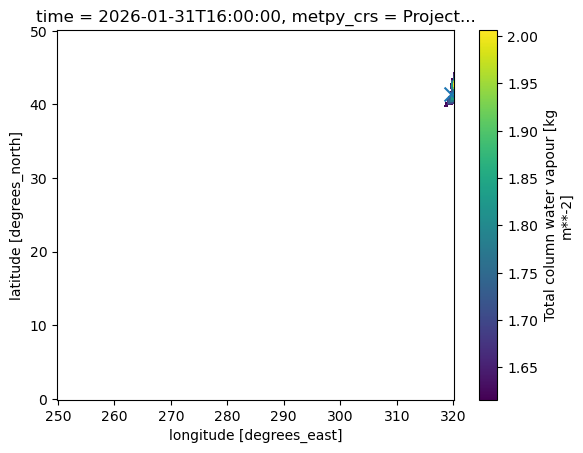

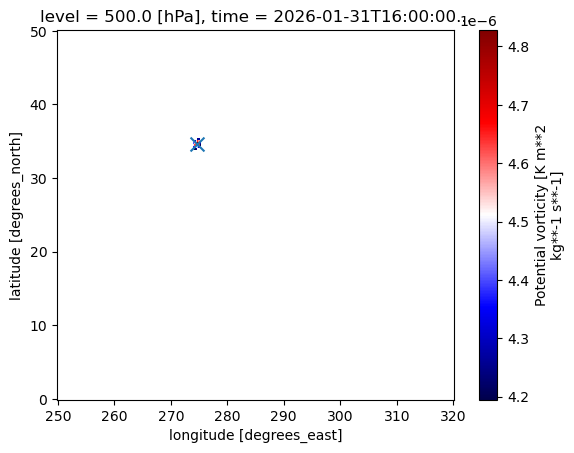

2026-01-31T20:00:00.000000000


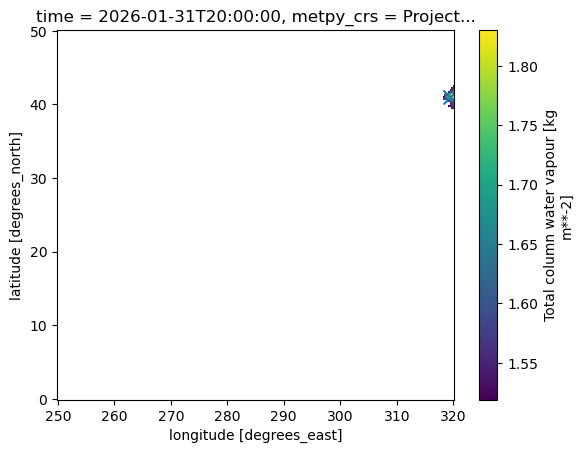

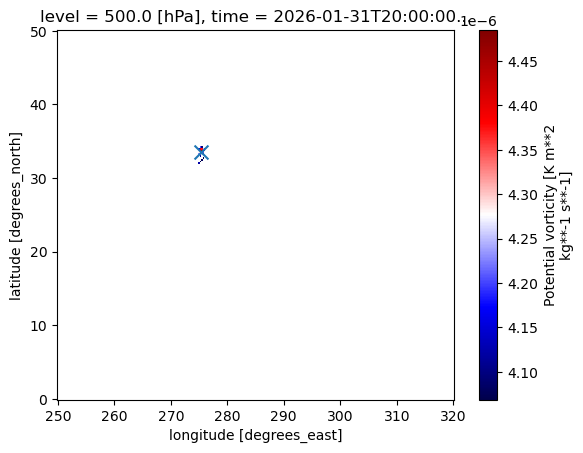

2026-02-01T00:00:00.000000000


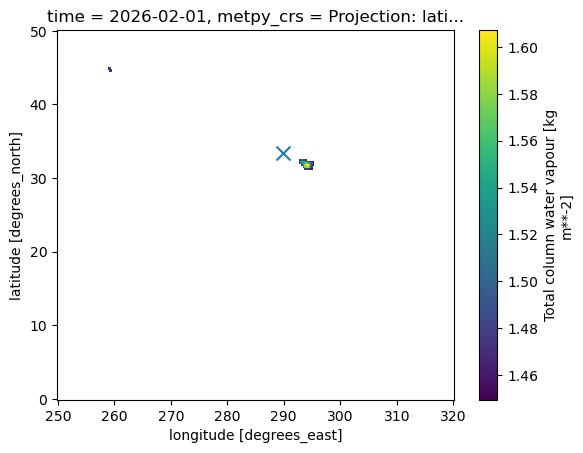

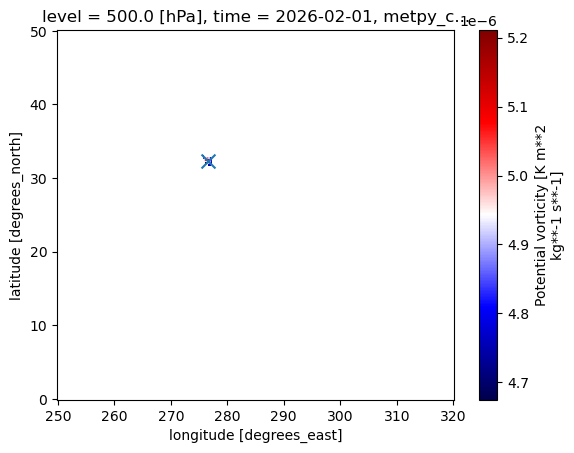

2026-02-01T04:00:00.000000000


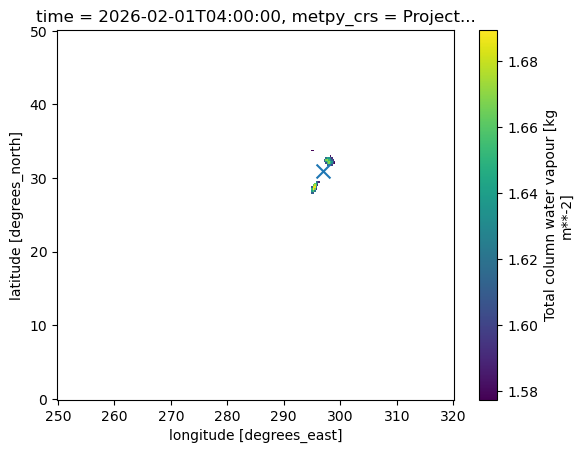

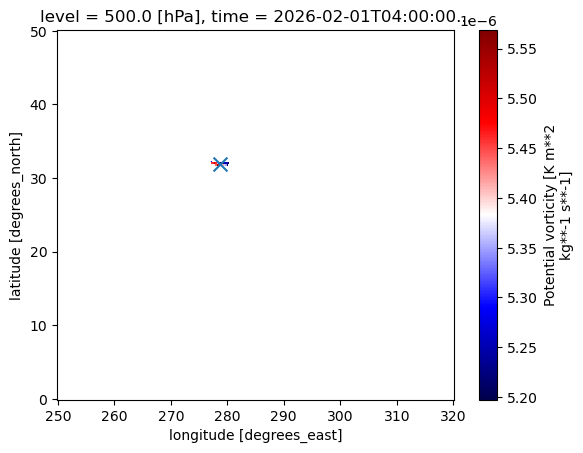

2026-02-01T08:00:00.000000000


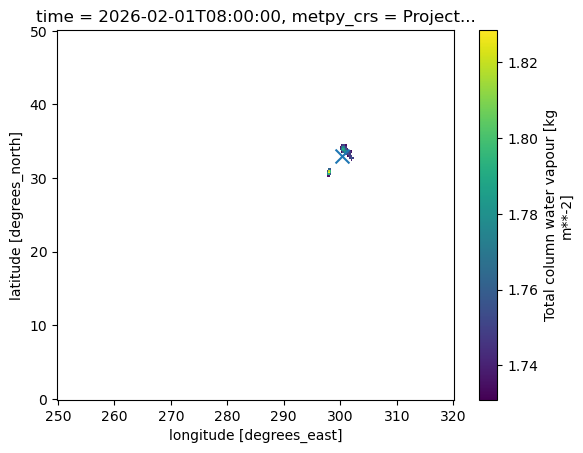

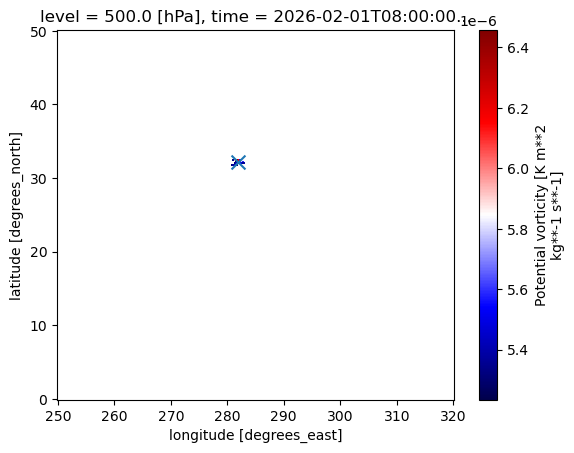

2026-02-01T12:00:00.000000000


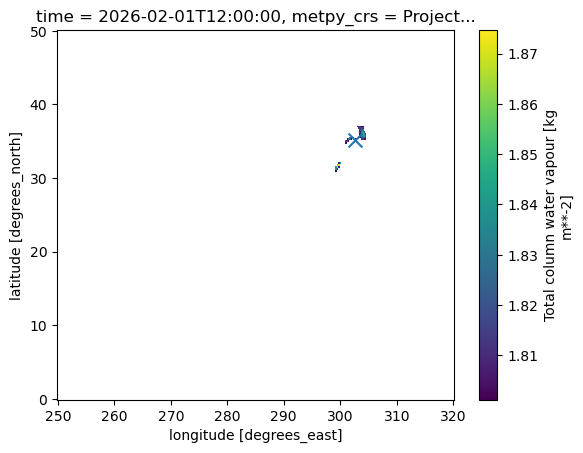

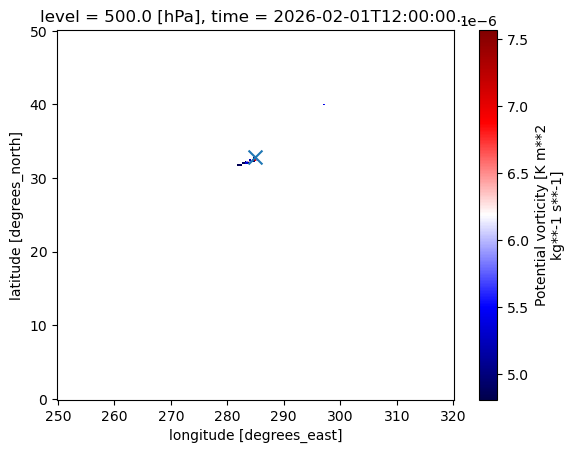

2026-02-01T16:00:00.000000000


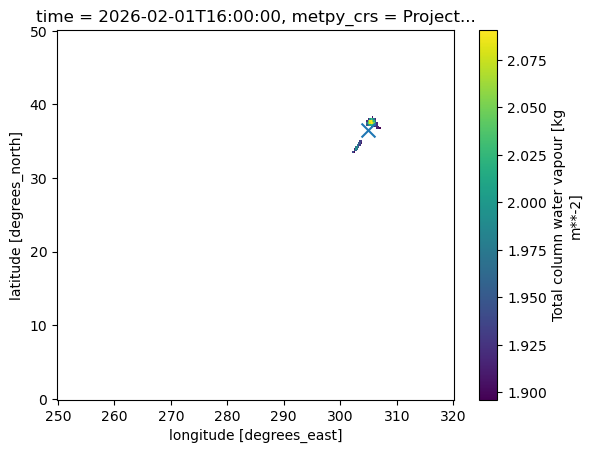

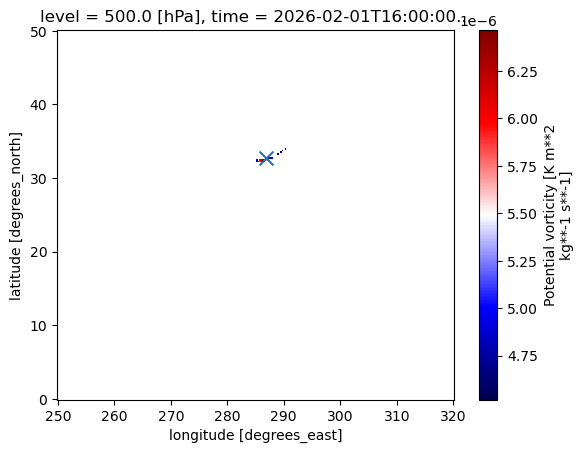

2026-02-01T20:00:00.000000000


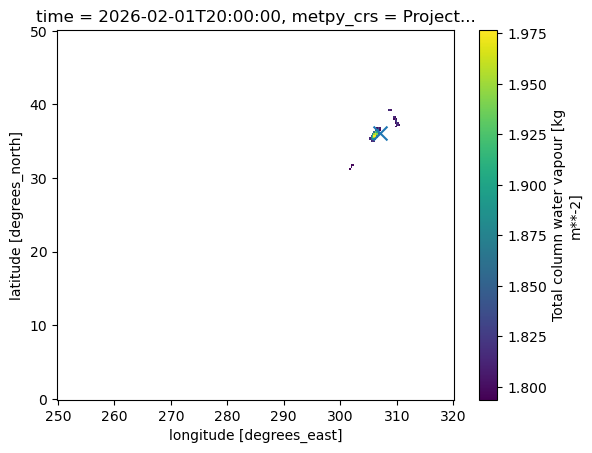

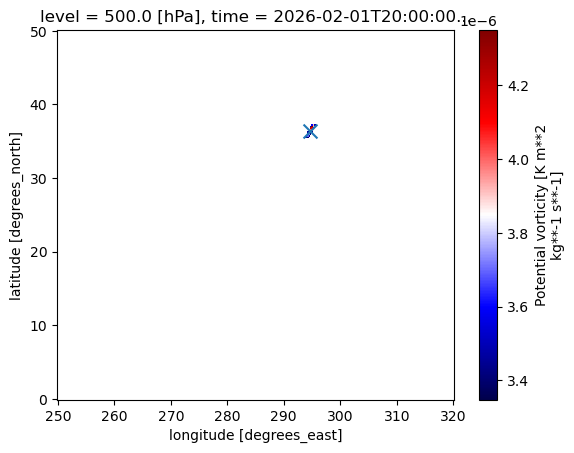

2026-02-02T00:00:00.000000000


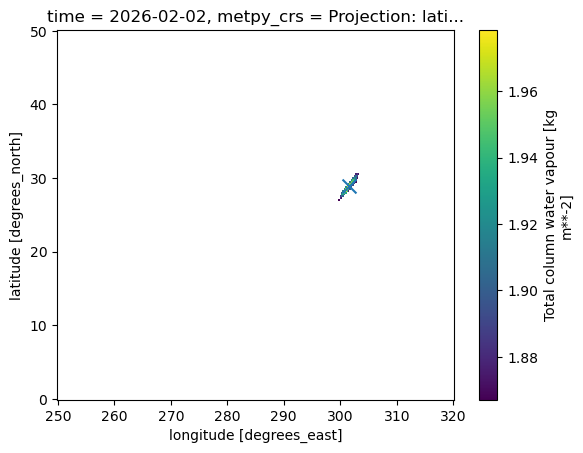

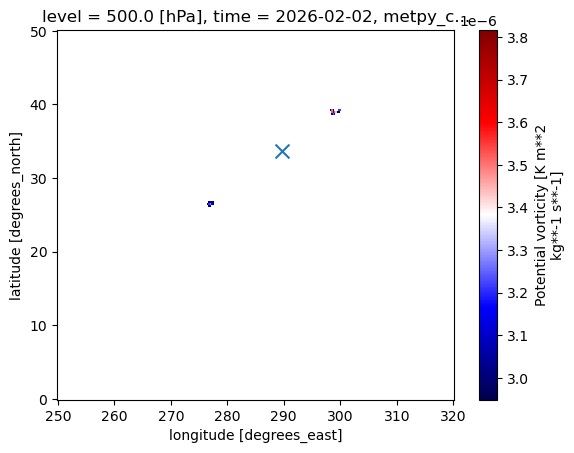

2026-02-02T04:00:00.000000000


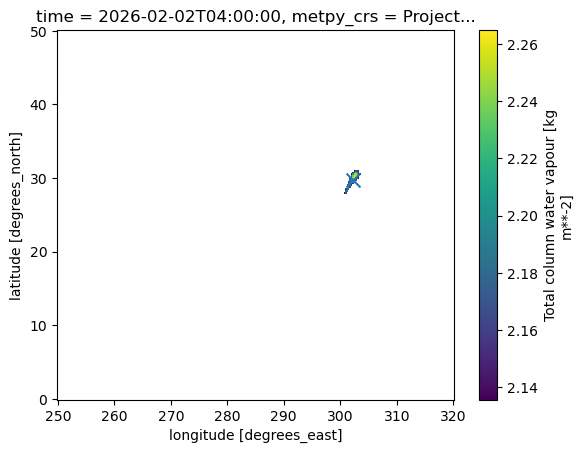

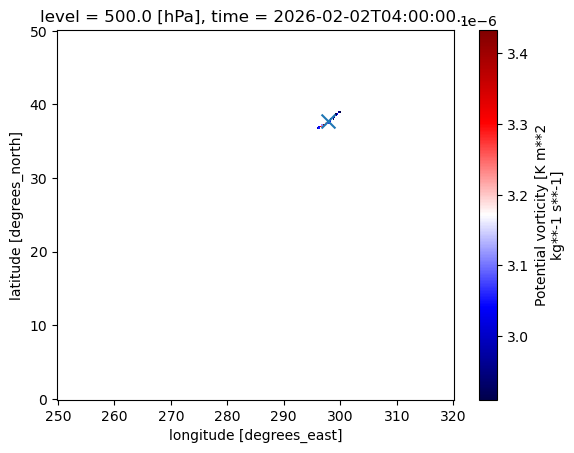

2026-02-02T08:00:00.000000000


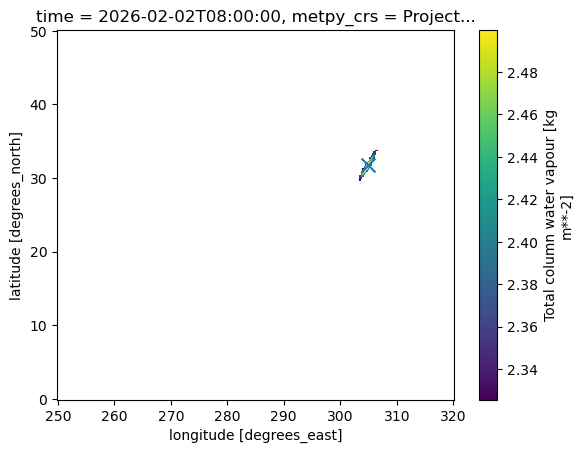

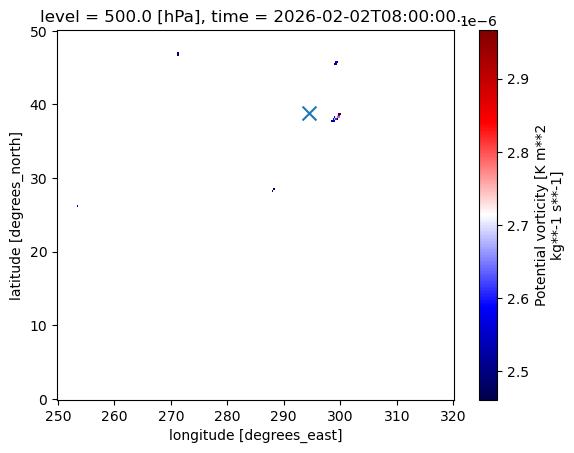

2026-02-02T12:00:00.000000000


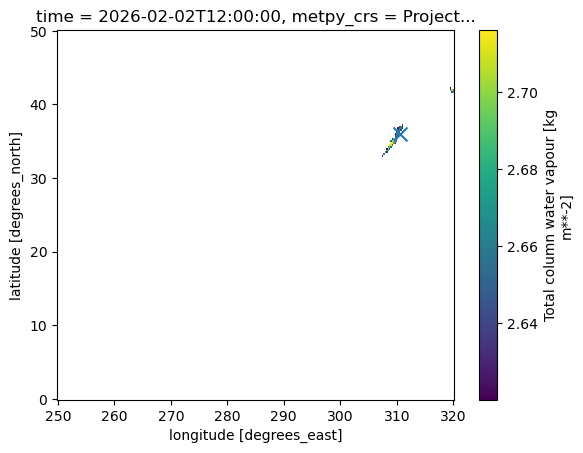

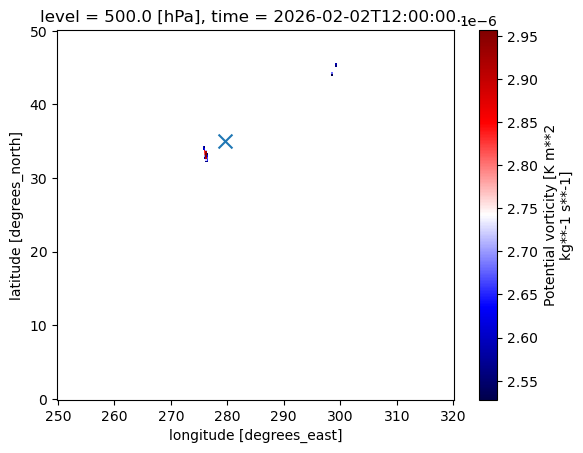

2026-02-02T16:00:00.000000000


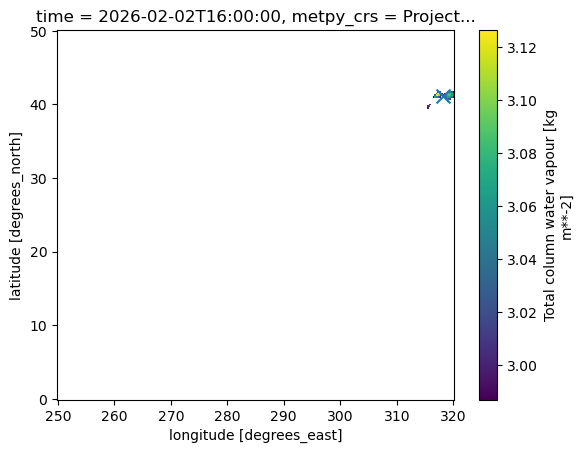

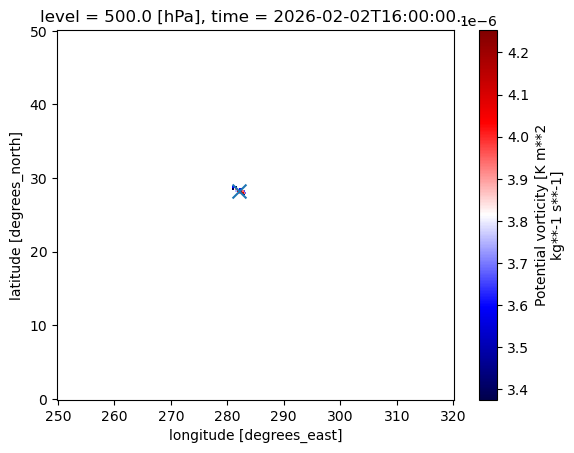

2026-02-02T20:00:00.000000000


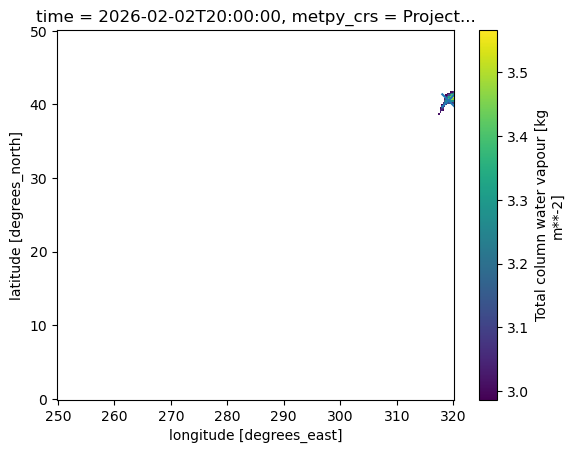

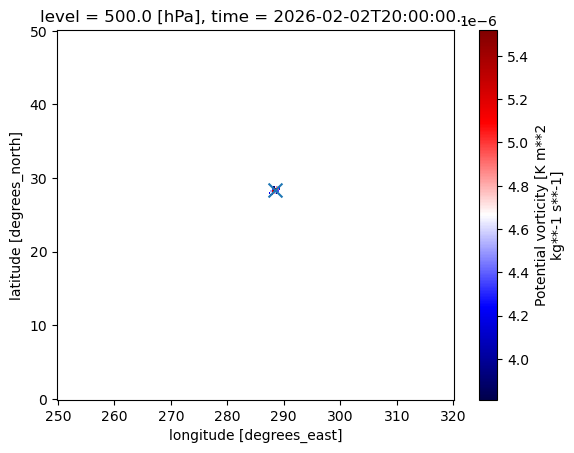

In [6]:
### LOOPING ###

times = []
distances = []

vt_lats = []
vt_lons = []

pv_lats = []
pv_lons = []

storm_times = dvt_storm.time.sel(
    time=slice('2026-01-31T012:00:00', '2026-02-02T023:00:00'))


for t in storm_times.time[::4]:
    print(t.values)

    # Select time
    vt = dvt_storm.sel(
        time=t,
        latitude=slice(latN, latS),
        longitude=slice(lonW, lonE)
    )

    pv = dpv_storm.sel(
        time=t,
     #   level=level,
        latitude=slice(latN, latS),
        longitude=slice(lonW, lonE)
    )

    # Thresholds
    zonal_mean = vt.mean(dim = "longitude")
    tcwv_anomaly = vt - zonal_mean
    
    # VT threshold
  #  threshold_vt = tcwv_anomaly.mean() + 2.6*tcwv_anomaly.std() # PLAY AROUND WITH THRESHOLD # anomaly

    #corridor_vt = tcwv_anomaly.where(tcwv_anomaly > threshold_vt)

    # VT normalized
    normalized_vt = tcwv_anomaly / zonal_mean
    threshold_vt = normalized_vt.quantile(.999) # normalized_vt.mean() + 2.6*normalized_vt.std() # PLAY AROUND WITH THRESHOLD # normalized

    corridor_vt = normalized_vt.where(normalized_vt > threshold_vt)

    
    # PV Threshold 
    '''
    # threshold_pv = pv.sel(latitude=slice(50, 20),longitude=slice(250, 310))
    threshold_pv = pv.where((pv.latitude >= 20) & (pv.longitude <= 300))
    threshold_pv = pv.mean() + 6.9*pv.std() ## PLAY AROUND WITH THRESHOLD
    center_pv = pv.where(pv > threshold_pv)
    '''

    pv_box = pv.where((pv.latitude >= 20) &(pv.longitude <= 300))
    threshold_pv =  pv_box.quantile(0.999) # pv_box.mean() + 6.9 * pv_box.std() #
    center_pv = pv_box.where(pv_box > threshold_pv)

    n_vt = corridor_vt.notnull().sum().item()
    n_pv = center_pv.notnull().sum().item()

    # Centroids
    weights_vt = corridor_vt.fillna(0)
    weights_pv = center_pv.fillna(0)

    lat_centroid_vt = (weights_vt * lats_2D).sum() / weights_vt.sum()
    lon_centroid_vt = (weights_vt * lons_2D).sum() / weights_vt.sum()

    lat_centroid_pv = (weights_pv * lats_2D).sum() / weights_pv.sum()
    lon_centroid_pv = (weights_pv * lons_2D).sum() / weights_pv.sum()

    # Distance
    distance_km = geodesic((float(lat_centroid_vt), float(lon_centroid_vt)), 
    (float(lat_centroid_pv), float((lon_centroid_pv)))).km

    times.append(t.values)
    distances.append(distance_km)

    vt_lats.append(float(lat_centroid_vt))
    vt_lons.append(float(lon_centroid_vt))

    pv_lats.append(float(lat_centroid_pv))
    pv_lons.append(float(lon_centroid_pv))

    '''
    tcwv_anomaly.plot()
    plt.show()
    
    pv.plot()
    plt.show()
    '''

    
    corridor_vt.plot()
    plt.scatter(
    float(lon_centroid_vt),
    float(lat_centroid_vt),
    marker='x',
    s=100
    )
    plt.show()

    center_pv.plot(cmap = 'seismic')
    plt.scatter(
    float(lon_centroid_pv),
    float(lat_centroid_pv),
    marker='x',
    s=100
    )
    plt.show()
    

#print(vt_lats, vt_lons)
#print(pv_lats, pv_lons)




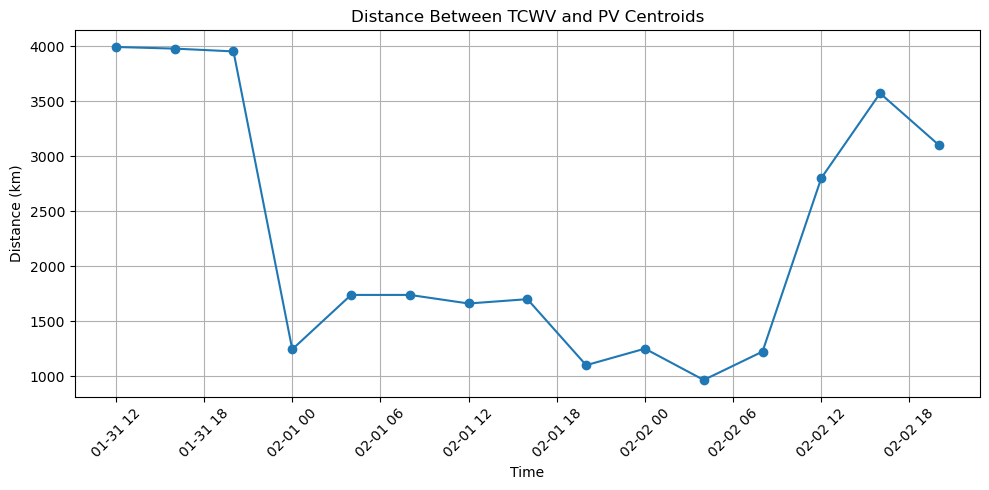

In [15]:
### PLOTTING OVER TIME ###
plt.figure(figsize=(10,5))
plt.plot(times, distances, marker = 'o')

plt.ylabel('Distance (km)')
plt.xlabel('Time')
plt.title('Distance Between TCWV and PV Centroids')


plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()

plt.show()

In [117]:
########### Calculate absolute and relative vorticity to plot #########
'''
rvor_2_1 = mpcalc.vorticity(uwnd_2_1,vwnd_2_1,dx=dx,dy=dy)
avor_2_1 = mpcalc.absolute_vorticity(uwnd_2_1,vwnd_2_1,dx=dx,dy=dy,latitude=lats_2D * units.degrees)
'''

vt_2_1.plot()
plt.show()

pv_2_1.plot()
plt.show()

rvor_2_1.plot()
plt.show()

avor_2_1.plot()
plt.show()

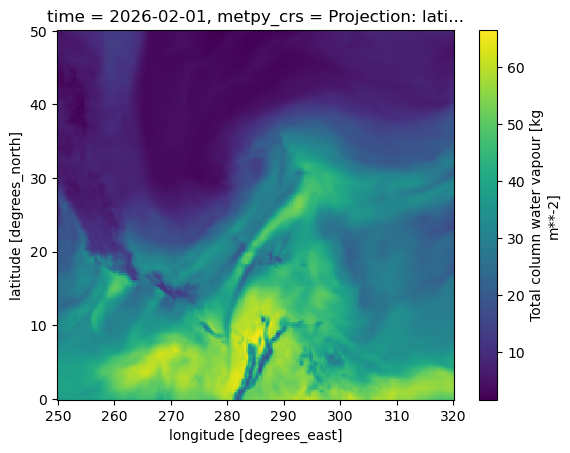

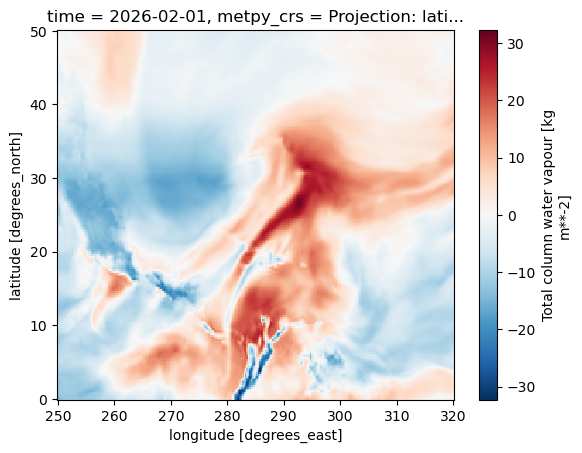

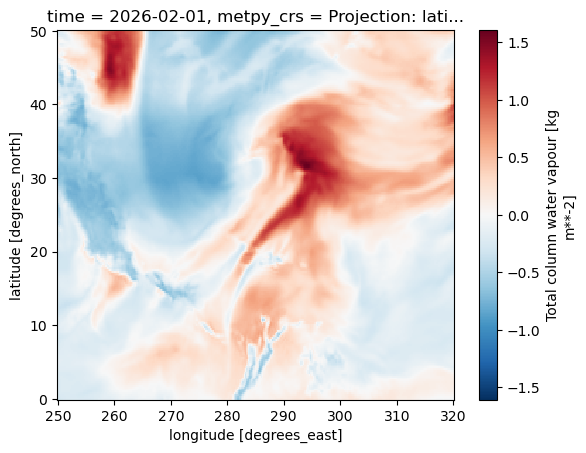

In [9]:
### ZONAL MEAN of TCWV and Thresholds ###

# Getting data
vt_2_1 = dvt_2_1.TCWV.metpy.sel(time=date,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
pv_2_1 = dpv_2_1.PV.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))

# Visualize original data
vt_2_1.plot()
plt.show()

#pv_2_1.plot()
#plt.show()

zonal_mean = vt_2_1.mean(dim = "longitude")
tcwv_anomaly = vt_2_1 - zonal_mean

# Plot anomaly
tcwv_anomaly.plot()
plt.show()

# VT normalized
normalized_vt = tcwv_anomaly / zonal_mean
normalized_vt.plot()
plt.show()

# VT threshold
threshold_vt = tcwv_anomaly.mean() + 3*tcwv_anomaly.std() # PLAY AROUND WITH THRESHOLD
corridor_vt = tcwv_anomaly.where(tcwv_anomaly > threshold_vt)


# PV Threshold 
threshold_pv = pv_2_1.mean() + 6.5*pv_2_1.std() ## PLAY AROUND WITH THRESHOLD
center_pv = pv_2_1.where(pv_2_1 > threshold_pv)


In [112]:
### Finding TPV Center, IVT Corridor ###

"""
# Finding maximum vapor
print("Max TCWV:", float(vt_2_1.max()))
print("Mean TCWV:", float(vt_2_1.mean()))
print("Std TCWV:", float(vt_2_1.std()))

# Finding maximum vorticity
print("Max PV:", float(pv_2_1.max()))
print("Mean PV:", float(pv_2_1.mean()))
print("Std PV:", float(pv_2_1.std()))
"""
'''
# Visualizing vapor threshold
threshold_vt = vt_2_1.mean() + 2*vt_2_1.std() # PLAY AROUND WITH THRESHOLD
corridor_vt = vt_2_1.where(vt_2_1 > threshold_vt)
corridor_vt.plot()
plt.title('High TCWV Region')
plt.show()



# Weighted avg
weights_vt = corridor_vt.fillna(0)

lat_centroid_vt = (weights_vt * lats_2D).sum() / weights_vt.sum()
lon_centroid_vt = (weights_vt * lons_2D).sum() / weights_vt.sum()

print("Latitude centroid:", float(lat_centroid_vt))
print("Longitude centroid:", float(lon_centroid_vt))
'''

Latitude centroid: 26.880551386486996
Longitude centroid: 292.4326246869332


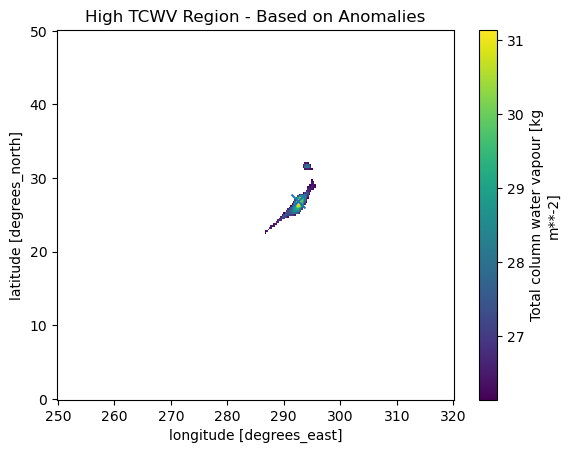

Latitude centroid: 32.67293046831916
Longitude centroid: 277.41490854959346


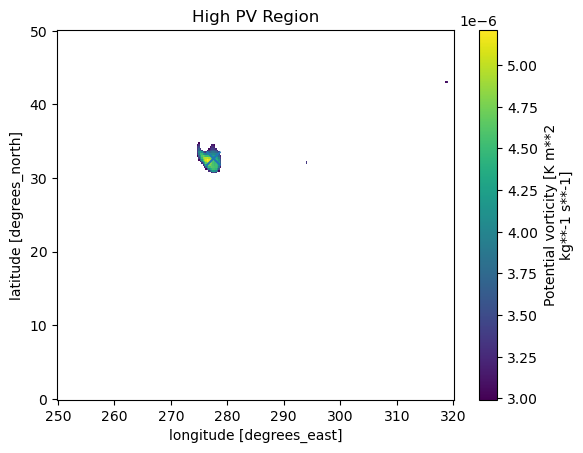

In [134]:
### Weighted Averages ###

# VT
weights_vt = corridor_vt.fillna(0)

lat_centroid_vt = (weights_vt * lats_2D).sum() / weights_vt.sum()
lon_centroid_vt = (weights_vt * lons_2D).sum() / weights_vt.sum()

print("Latitude centroid:", float(lat_centroid_vt))
print("Longitude centroid:", float(lon_centroid_vt))


corridor_vt.plot()
plt.title('High TCWV Region - Based on Anomalies')
plt.scatter(float(lon_centroid_vt),float(lat_centroid_vt),marker='x',s=100)
plt.show()


# PV
weights_pv = center_pv.fillna(0)

lat_centroid_pv = (weights_pv * lats_2D).sum() / weights_pv.sum()
lon_centroid_pv = (weights_pv * lons_2D).sum() / weights_pv.sum()

print("Latitude centroid:", float(lat_centroid_pv))
print("Longitude centroid:", float(lon_centroid_pv))

center_pv.plot()
plt.title('High PV Region')
plt.scatter(float(lon_centroid_pv),float(lat_centroid_pv),marker='x',s=100)
plt.show()

In [135]:
### Distance Calculation ###

distance_km = geodesic(
    (float(lat_centroid_vt), float(lon_centroid_vt)),
    (float(lat_centroid_pv), float(lon_centroid_pv))
).km

print(f"Distance = {distance_km:.1f} km")

Distance = 1585.8 km
